In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow keras yfinance plotly streamlit

In [4]:
import yfinance as yf

df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')
df.to_csv('AAPL_stock.csv')
print("Data downloaded successfully!")
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!
(2264, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511063,24.042136,23.325188,23.962475,257142000
2015-01-06,23.513271,23.772169,23.152583,23.575230,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
df = pd.read_csv('AAPL_stock.csv', skiprows=2, index_col=0, parse_dates=True)
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
print("Dataset loaded successfully!")
print(df.shape)
print(df.head())

Dataset loaded successfully!
(2264, 5)
                Close       High        Low       Open     Volume
Date                                                             
2015-01-02  24.192602  24.659504  23.754466  24.648440  212818400
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000
2015-01-06  23.513271  23.772169  23.152583  23.575230  263188400
2015-01-07  23.842979  23.942555  23.610634  23.721274  160423600
2015-01-08  24.759085  24.816618  24.053199  24.170479  237458000


In [8]:
print(df.head())
print(df.tail())


                Close       High        Low       Open     Volume
Date                                                             
2015-01-02  24.192602  24.659504  23.754466  24.648440  212818400
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000
2015-01-06  23.513271  23.772169  23.152583  23.575230  263188400
2015-01-07  23.842979  23.942555  23.610634  23.721274  160423600
2015-01-08  24.759085  24.816618  24.053199  24.170479  237458000
                 Close        High         Low        Open    Volume
Date                                                                
2023-12-22  191.433090  193.222829  190.810137  192.995392  37149600
2023-12-26  190.889267  191.719862  190.671728  191.442997  28919300
2023-12-27  190.988129  191.334217  188.951188  190.335527  48087700
2023-12-28  191.413345  192.481259  191.007931  191.967075  34049900
2023-12-29  190.375046  192.224110  189.583997  191.729707  42672100


In [9]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2264 entries, 2015-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2264 non-null   float64
 1   High    2264 non-null   float64
 2   Low     2264 non-null   float64
 3   Open    2264 non-null   float64
 4   Volume  2264 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 106.1 KB
None
             Close         High          Low         Open        Volume
count  2264.000000  2264.000000  2264.000000  2264.000000  2.264000e+03
mean     81.243767    82.066766    80.338945    81.175473  1.237614e+08
std      55.887047    56.459302    55.253230    55.832494  6.818417e+07
min      20.565865    20.868639    20.367811    20.488465  2.404830e+07
25%      32.753833    32.949665    32.573033    32.765974  7.831732e+07
50%      51.125853    51.935671    50.752277    51.272453  1.056556e+08
75%     138.759815   140.442892   136.263585   138.70148

In [10]:
print(df.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


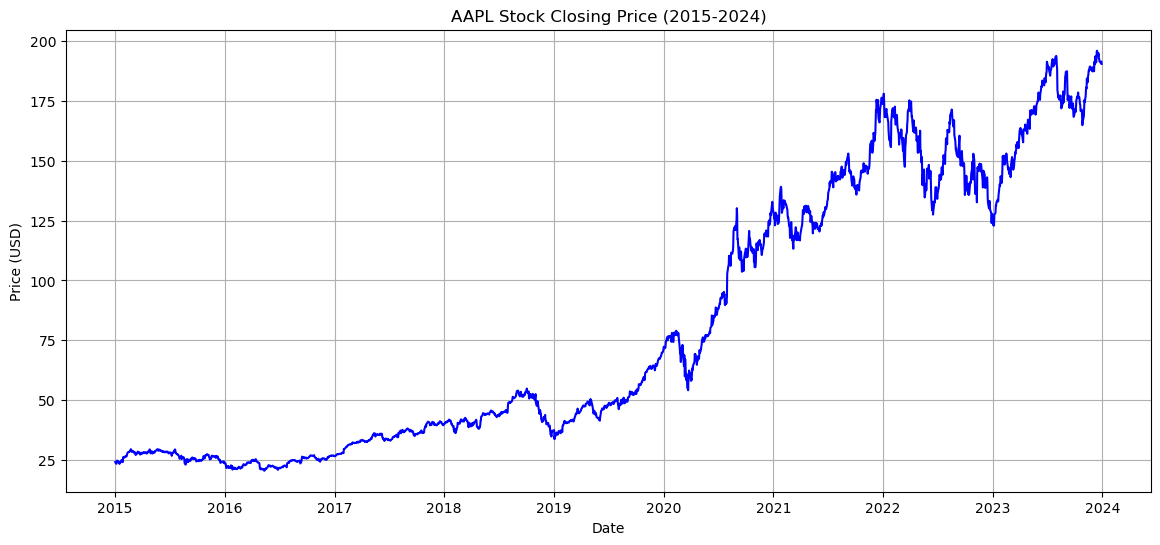

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], color='blue')
plt.title('AAPL Stock Closing Price (2015-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

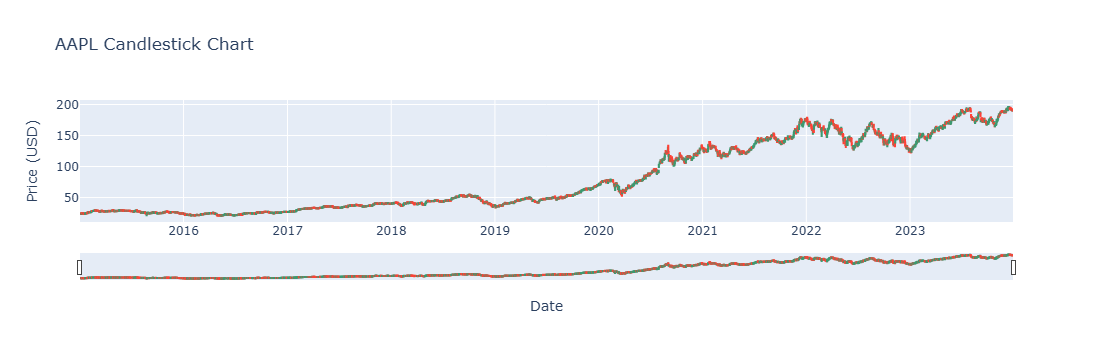

In [12]:
fig = go.Figure()
fig.add_trace(go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
))
fig.update_layout(title='AAPL Candlestick Chart', xaxis_title='Date', yaxis_title='Price (USD)')
fig.show()

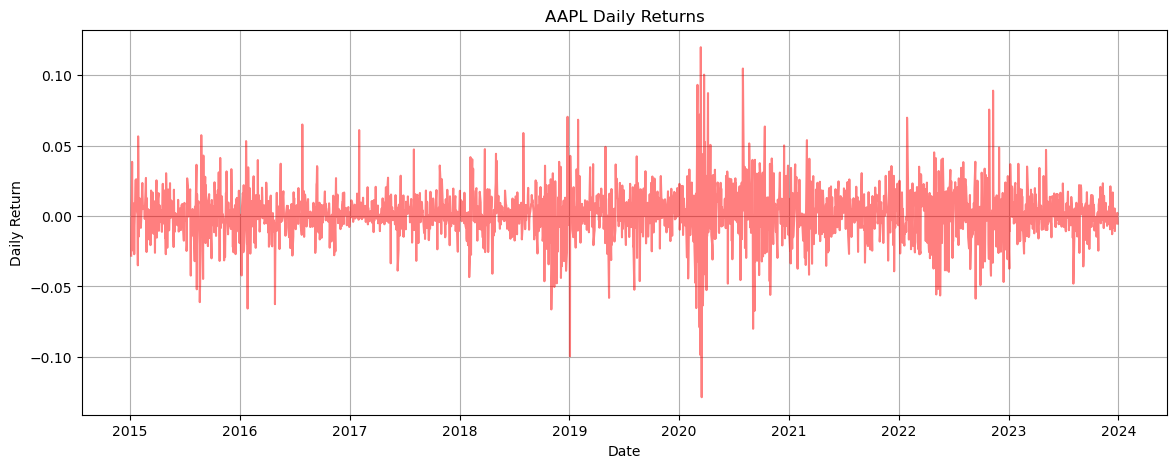

In [13]:
df['Daily Return'] = df['Close'].pct_change()
plt.figure(figsize=(14, 5))
plt.plot(df['Daily Return'], color='red', alpha=0.5)
plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

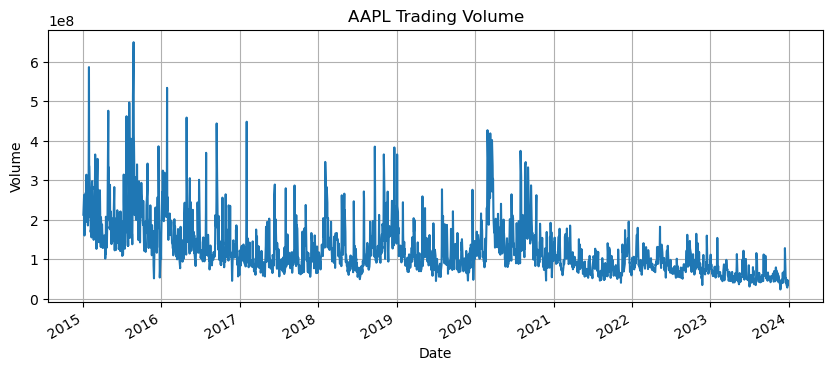

In [14]:
plt.figure(figsize=(10, 4))
df['Volume'].plot()
plt.title('AAPL Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

In [15]:
data = df['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
print("Data scaled successfully!")
print(scaled_data.shape)

Data scaled successfully!
(2264, 1)


In [16]:
train_size = int(len(scaled_data) * 0.80)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]
print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 1811
Test size: 453


In [17]:
def create_sequences(data, sequence_length=60):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data)
X_test, y_test = create_sequences(test_data)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1751, 60, 1)
X_test shape: (393, 60, 1)


In [18]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=25))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - loss: 0.0052 - val_loss: 0.0017
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.0014 - val_loss: 0.0049
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 9.7680e-04 - val_loss: 0.0061
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - loss: 9.2338e-04 - val_loss: 0.0026
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 8.5551e-04 - val_loss: 0.0014
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 7.3584e-04 - val_loss: 0.0033
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 6.3608e-04 - val_loss: 0.0025
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 7.2301e-04 - val_loss: 0.0013
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 7.0896e-04 - val_loss: 0.0028
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - loss: 6.4651e-04 - val_loss: 0.0016


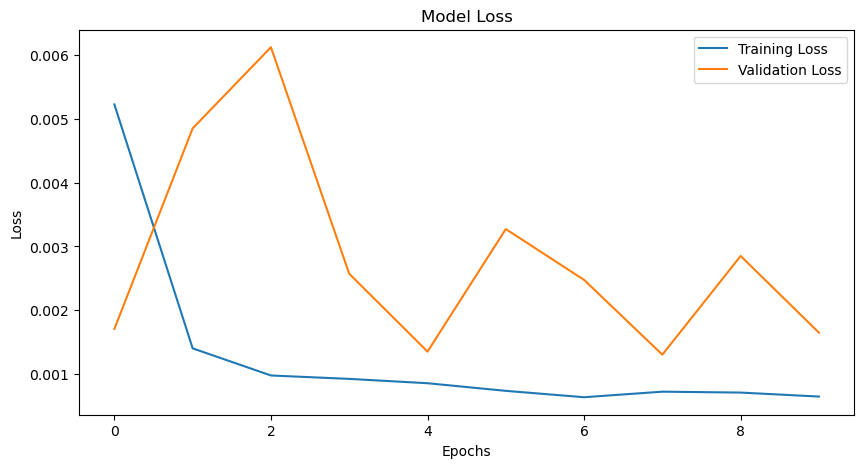

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [21]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step
MAE: 7.54
RMSE: 8.71


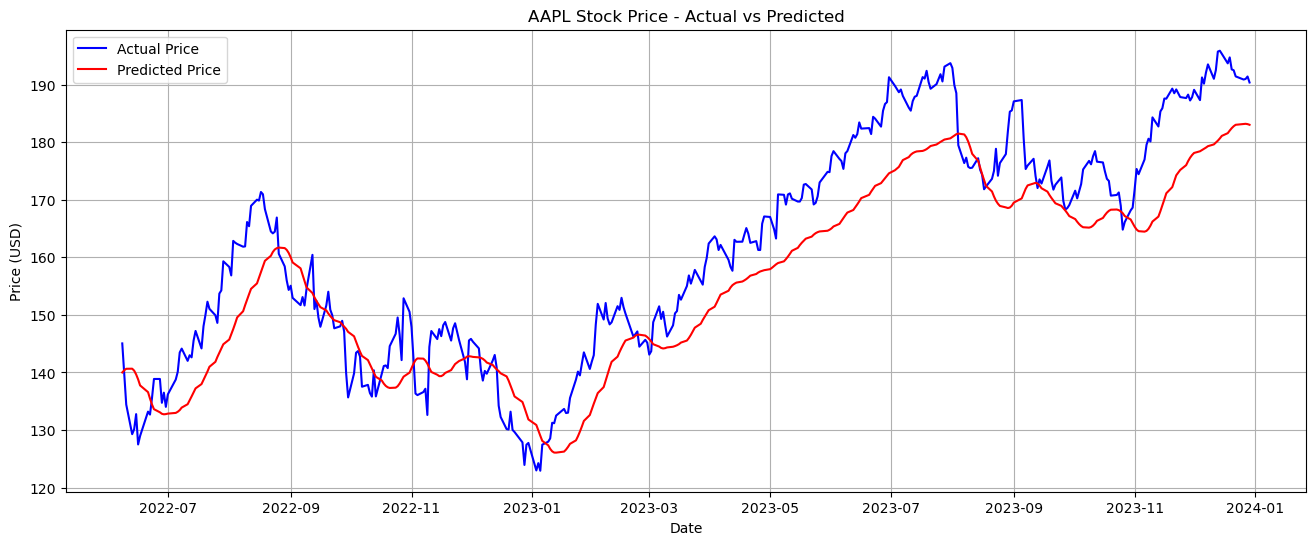

In [22]:
plt.figure(figsize=(16, 6))
plt.plot(df.index[len(df)-len(y_test_actual):], y_test_actual, color='blue', label='Actual Price')
plt.plot(df.index[len(df)-len(predictions):], predictions, color='red', label='Predicted Price')
plt.title('AAPL Stock Price - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

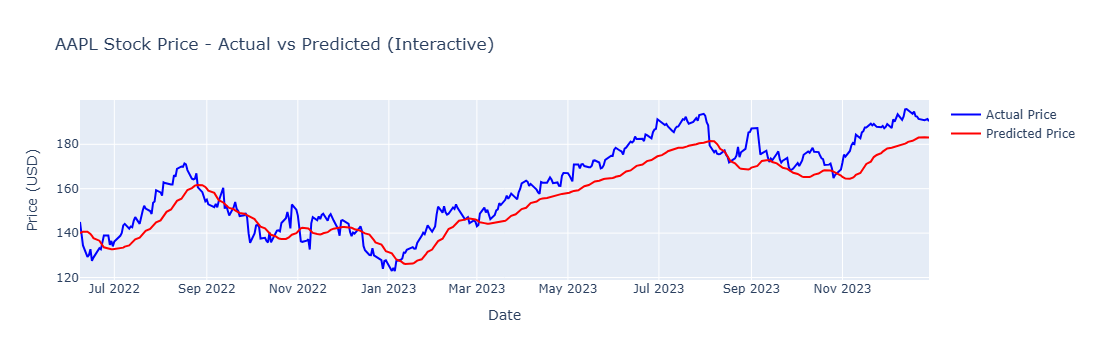

In [23]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.index[len(df)-len(y_test_actual):],
    y=y_test_actual.flatten(),
    name='Actual Price',
    line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=df.index[len(df)-len(predictions):],
    y=predictions.flatten(),
    name='Predicted Price',
    line=dict(color='red')
))
fig.update_layout(
    title='AAPL Stock Price - Actual vs Predicted (Interactive)',
    xaxis_title='Date',
    yaxis_title='Price (USD)'
)
fig.show()

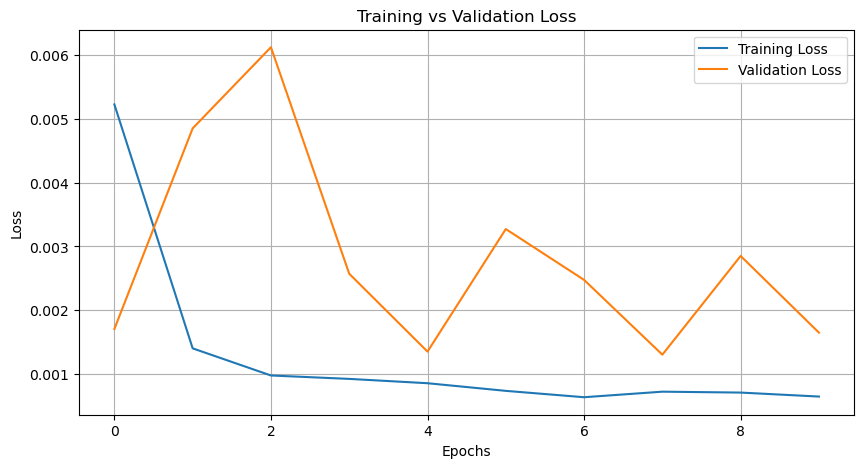

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

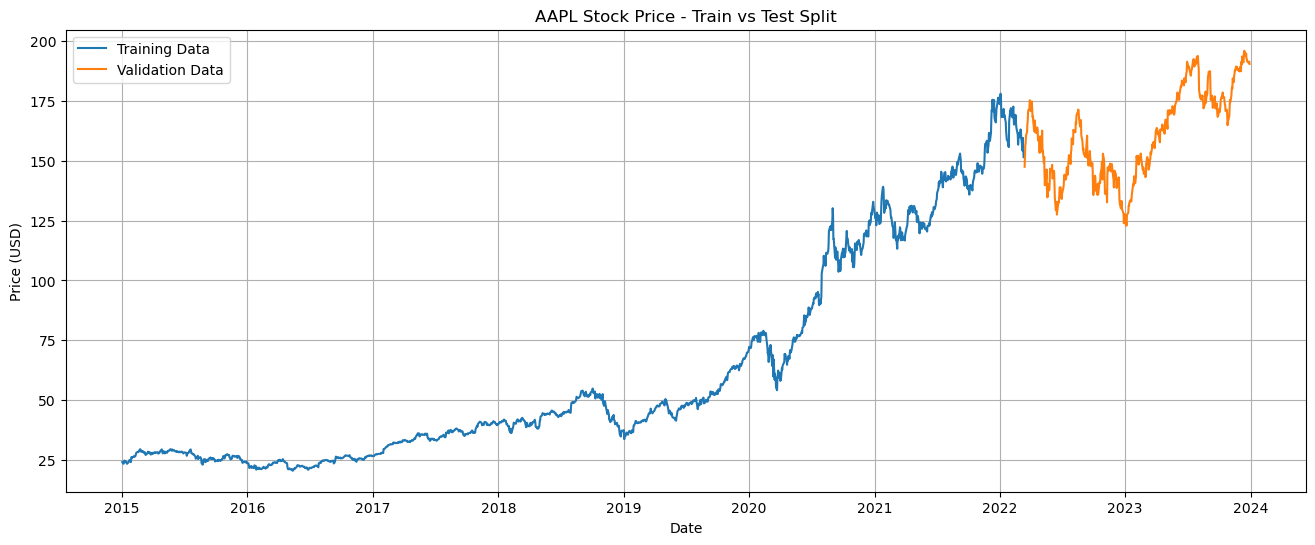

In [25]:
train = df['Close'][:train_size]
valid = df['Close'][train_size:]

plt.figure(figsize=(16, 6))
plt.plot(train, label='Training Data')
plt.plot(valid, label='Validation Data')
plt.title('AAPL Stock Price - Train vs Test Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
model.save('lstm_model.keras')
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print("Model & Scaler saved successfully!")

Model & Scaler saved successfully!
